In [1]:
# Import Libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
# Load Dataset
data = load_breast_cancer()


In [5]:

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

Before SMOTE:
1    357
0    212
Name: count, dtype: int64


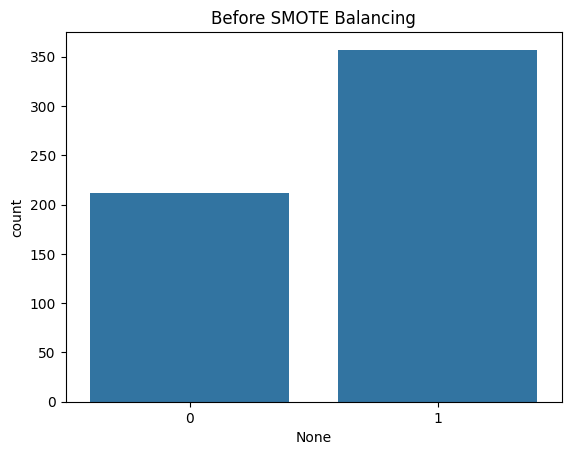

In [6]:
# Show class distribution before balancing
print("Before SMOTE:")
print(y.value_counts())  # 0 = Malignant, 1 = Benign

sns.countplot(x=y)
plt.title("Before SMOTE Balancing")
plt.show()

In [7]:
# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

c:\Users\Mani\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



After SMOTE:
1    286
0    286
Name: count, dtype: int64


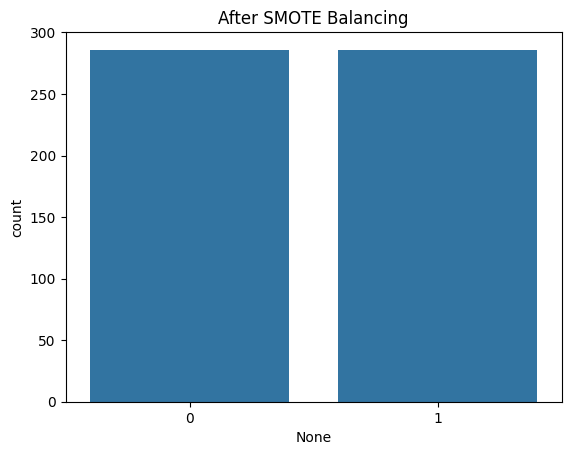

In [8]:

# Show class distribution after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

sns.countplot(x=y_train_smote)
plt.title("After SMOTE Balancing")
plt.show()

In [9]:
# Train Model
model = LogisticRegression(max_iter=10000)
model.fit(X_train_smote, y_train_smote)

# Predict
y_pred = model.predict(X_test)

In [10]:
# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [11]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[40  3]
 [ 1 70]]
